**CREDIT CARD FRAUD DETECTION**

**Binary Classification | Logistic Regression / Random Forest / Gradient Boosting / ANN**

1. ALL IMPORTS

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2. LOAD & INSPECT THE DATA

In [120]:
df = pd.read_csv('/content/creditcard.csv')

In [121]:
df.shape

(284807, 31)

In [122]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [124]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [126]:
# Class = the target column (0 = normal transaction, 1 = fraud)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


3. CLEAN THE DATA

In [128]:
df.isnull().sum() #no missing values

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [129]:
df.duplicated().sum()

np.int64(1081)

In [130]:
df.drop_duplicates(inplace=True)

In [132]:
df.duplicated().sum()

np.int64(0)

In [133]:
df.shape

(283726, 31)

4. EDA [EXPLORATORY DATA ANALYSIS (5 visualizations)]

In [134]:
# Graph 1 — Class imbalance

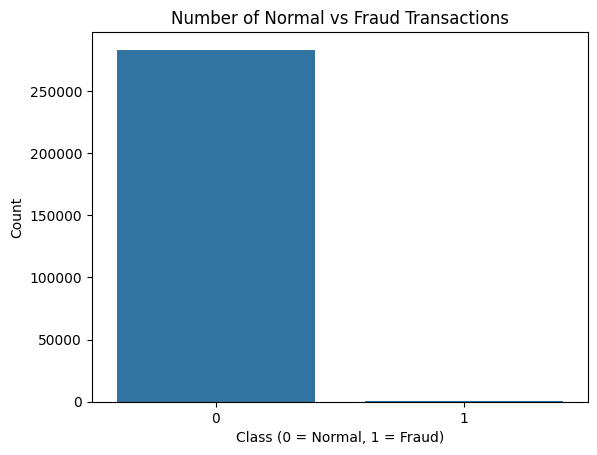

In [135]:
sns.countplot(x='Class', data=df)
plt.title("Number of Normal vs Fraud Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [136]:
# Graph 2 — Amount distribution

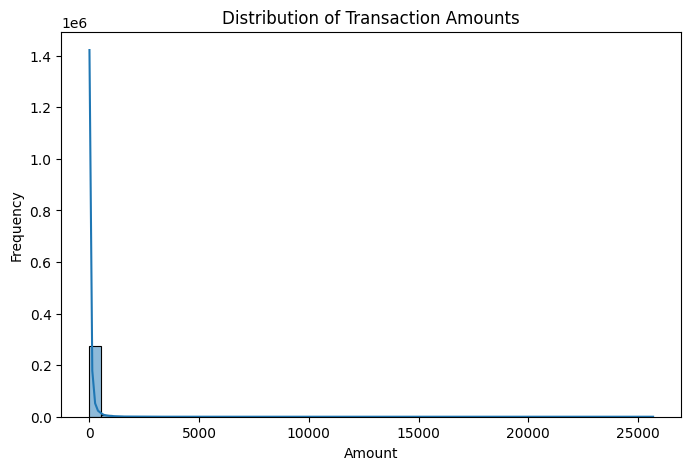

In [137]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [138]:
# Graph 3 — Amount by Class

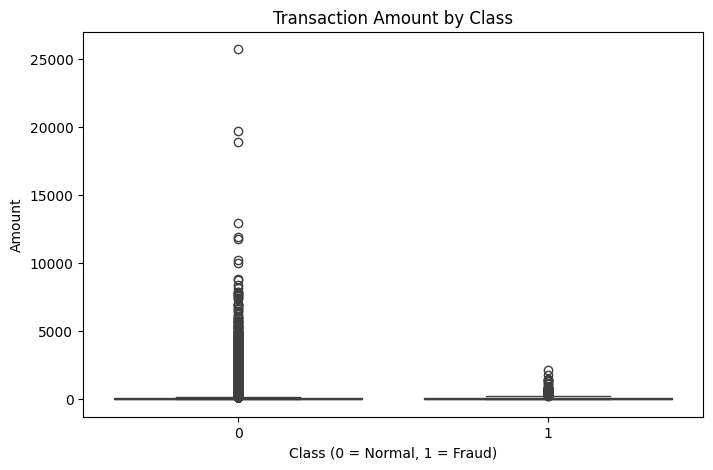

In [139]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()

In [140]:
# Graph 4 — Time distribution

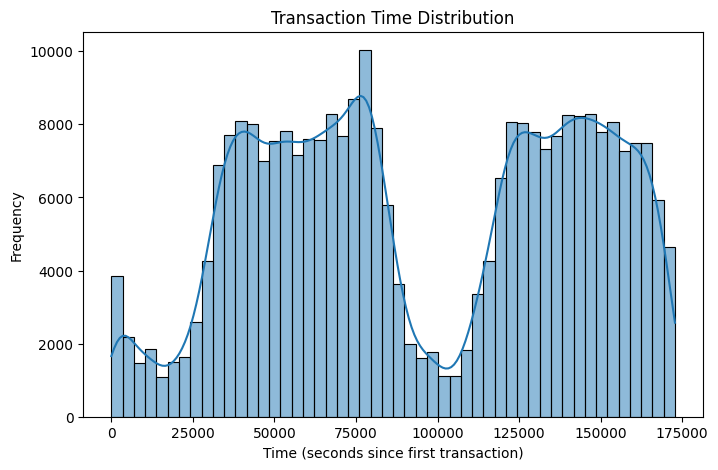

In [141]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Time'], bins=50, kde=True)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Frequency")
plt.show()

In [142]:
# Graph 5 — Correlation heatmap

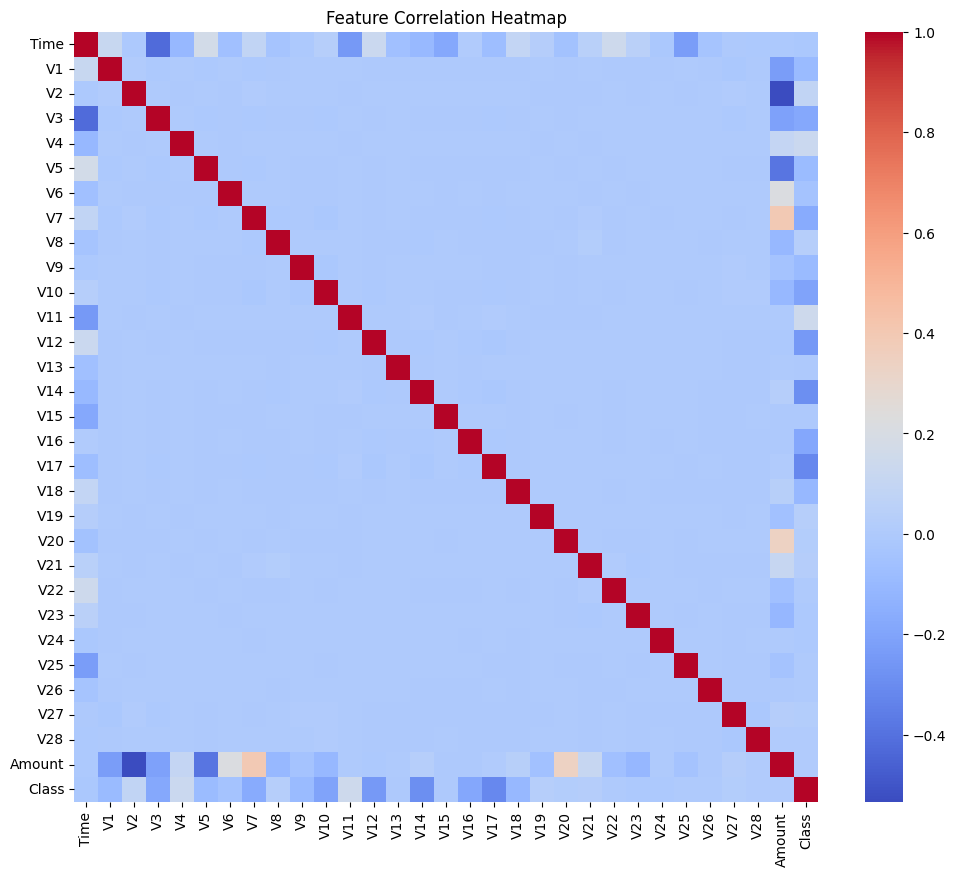

In [143]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

5. FEATURE SCALING

In [144]:
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df[['Amount']])
df['scaled_Time'] = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)

In [145]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_Amount,scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073813,-1.996781


6. TRAIN / TEST SPLIT

In [146]:
X = df.drop('Class', axis=1)
y = df['Class']

In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [148]:
print(X_train.shape)
print(X_test.shape)

(226980, 30)
(56746, 30)


7. TRAIN & EVALUATE ALL 4 MODELS

In [149]:
results = {}  # will store each model's scores for the comparison table later

In [150]:
#Model 1: Logistic Regression

In [151]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression
Accuracy: 0.9991365030134283
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



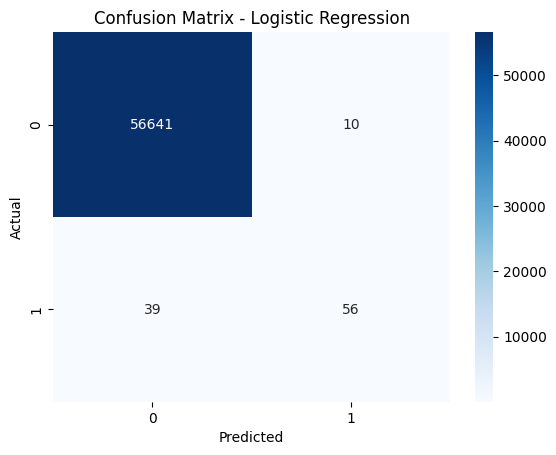

In [152]:
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [153]:
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1': f1_score(y_test, y_pred_log)
}

In [154]:
#Model 2: Random Forest

In [155]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9995241955380115
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



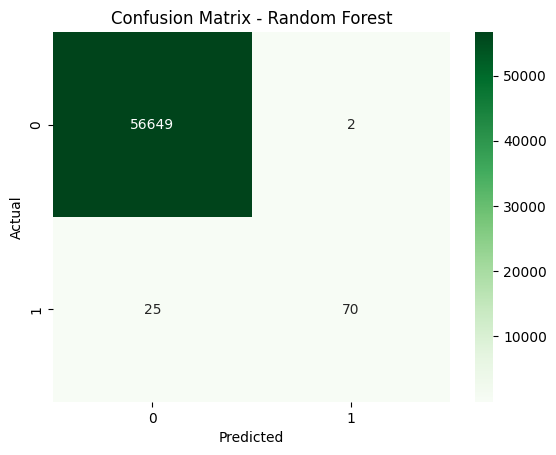

In [156]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [157]:
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf)
}

In [158]:
#Model 3: Gradient Boosting

In [159]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy: 0.9992598597257957
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.65      0.75        95

    accuracy                           1.00     56746
   macro avg       0.94      0.83      0.87     56746
weighted avg       1.00      1.00      1.00     56746



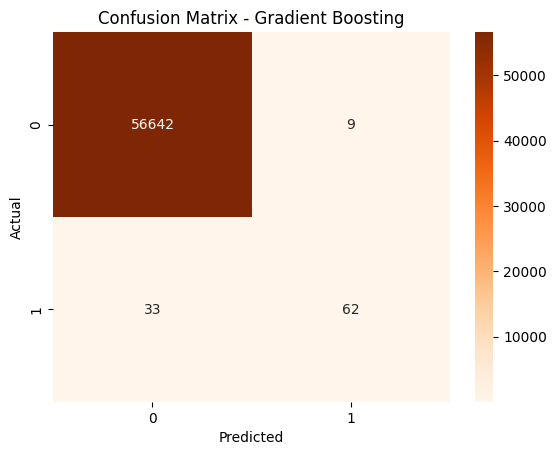

In [160]:
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [161]:
results['Gradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb)
}

In [162]:
#Model 4: ANN

In [164]:
ann_model = Sequential()
ann_model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
ann_model.add(Dense(8, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9975 - loss: 0.0134 - val_accuracy: 0.9995 - val_loss: 0.0031
Epoch 2/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9995 - val_loss: 0.0027
Epoch 3/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0.0028 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 4/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9995 - val_loss: 0.0026
Epoch 5/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0025 - val_accuracy: 0.9995 - val_loss: 0.0025
Epoch 6/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 7/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 8/10
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0

In [165]:
#Training curves

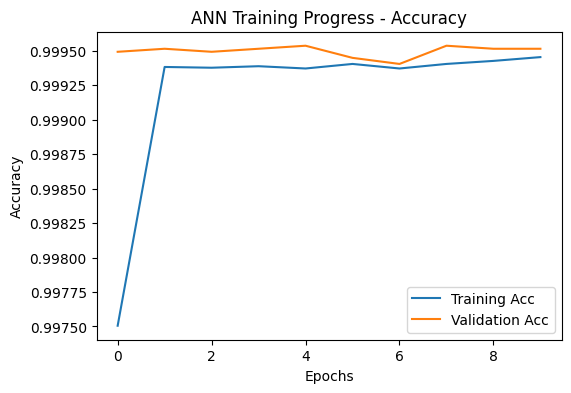

In [166]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Acc')
plt.plot(history.history['val_accuracy'], label='Validation Acc')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("ANN Training Progress - Accuracy")
plt.show()

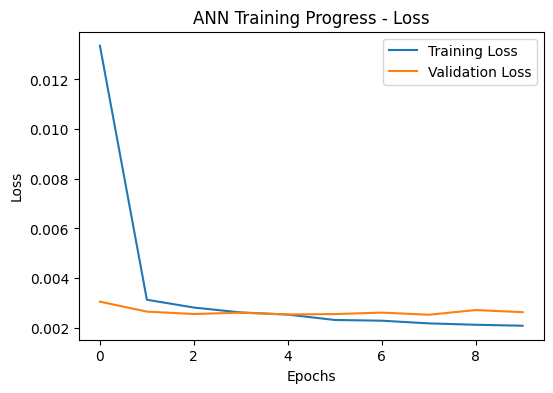

In [167]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("ANN Training Progress - Loss")
plt.show()

In [168]:
loss, acc = ann_model.evaluate(X_test, y_test)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9994 - loss: 0.0036


In [169]:
y_pred_prob_ann = ann_model.predict(X_test)
y_pred_ann = (y_pred_prob_ann >= 0.5).astype(int)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [170]:
print("ANN")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print(classification_report(y_test, y_pred_ann))

ANN
Accuracy: 0.9994184612131252
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



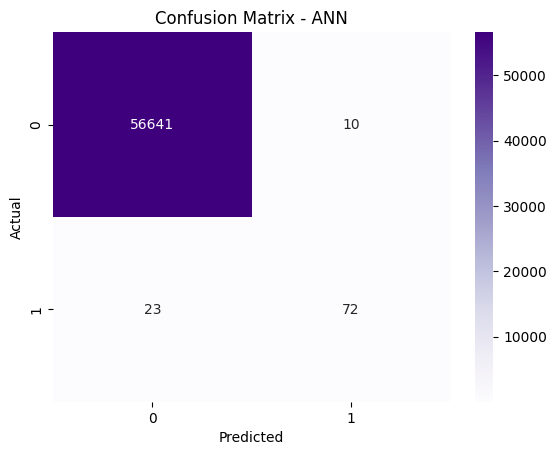

In [171]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [172]:
results['ANN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_ann),
    'Precision': precision_score(y_test, y_pred_ann),
    'Recall': recall_score(y_test, y_pred_ann),
    'F1': f1_score(y_test, y_pred_ann)
}

9. MODEL COMPARISON

                     Accuracy  Precision    Recall        F1
Logistic Regression  0.999137   0.848485  0.589474  0.695652
Random Forest        0.999524   0.972222  0.736842  0.838323
Gradient Boosting    0.999260   0.873239  0.652632  0.746988
ANN                  0.999418   0.878049  0.757895  0.813559


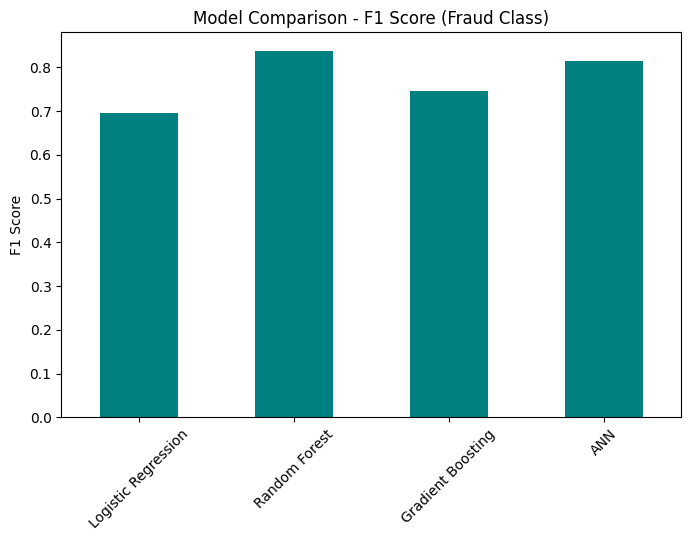

In [173]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df['F1'].plot(kind='bar', figsize=(8, 5), color='teal')
plt.title("Model Comparison - F1 Score (Fraud Class)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.show()

10. INTERPRETATION (Feature Importance)

In [174]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False).head(10)

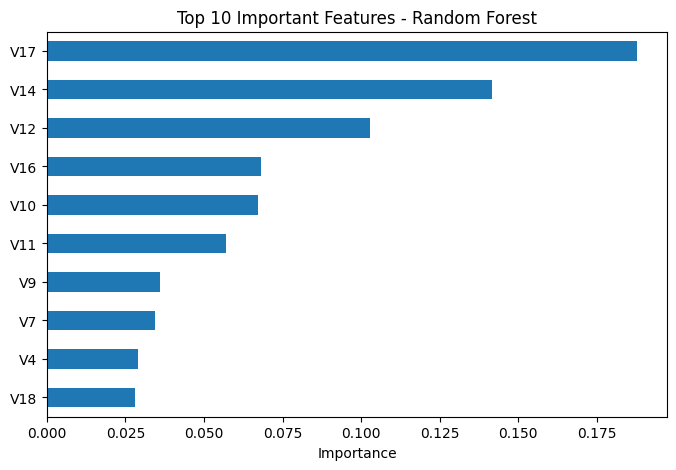

In [175]:
plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh')
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

12. FINAL PREDICTION DEMO

In [180]:
normal_sample = X_test[y_test == 0].iloc[:3]
fraud_sample = X_test[y_test == 1].iloc[:2]

sample = pd.concat([normal_sample, fraud_sample])
actual = y_test.loc[sample.index]

predicted = rf_model.predict(sample)

demo_df = sample.copy()
demo_df['Actual'] = actual.values
demo_df['Predicted'] = predicted
print(demo_df)

              V1        V2        V3        V4        V5        V6        V7  \
86568   1.228821 -0.063408  0.274145  0.647465 -0.048135  0.372073 -0.224231   
251557 -0.203154  1.176678 -0.759595 -0.518472  0.629649 -0.721675  0.638893   
20232  -1.672836  1.401297  1.503940  2.175491  0.699791  1.062139  1.114364   
116139 -1.548788  1.808698 -0.953509  2.213085 -2.015728 -0.913457 -2.356013   
95597  -2.923827  1.524837 -3.018758  3.289291 -5.755542  2.218276 -0.509995   

              V8        V9       V10  ...       V23       V24       V25  \
86568   0.079939  0.640759 -0.273054  ... -0.151661 -0.700372  0.598550   
251557  0.243377 -0.157488 -0.506595  ... -0.082753  0.508386 -0.710906   
20232  -0.535822 -0.252983  3.071219  ... -0.280083 -0.846468 -0.155456   
116139  1.197169 -1.678374 -3.538650  ...  0.059037  0.343200 -0.468938   
95597  -3.569444 -1.016592 -4.320536  ... -4.288639  0.563797 -0.949451   

             V26       V27       V28  scaled_Amount  scaled_Time  Ac

13. Conclusion: After comparing all four models, Random Forest performed the best with the highest F1-Score of 0.838.
Although all models gave very high accuracy, accuracy is not a reliable metric in this project because the dataset is highly imbalanced. Therefore, Precision, Recall, and F1-Score were used for proper evaluation.
Random Forest showed the best balance between detecting fraud cases and avoiding false alarms. The most important features for prediction were V17, V14, and V12.
Overall, the project successfully demonstrates data preprocessing, exploratory data analysis, model training, evaluation, and interpretation